In [2]:
from pathlib import Path
from jax import config
import jax.numpy as np
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.lensing_utils_alt import (
    compute_lensed_angles_approx,
    get_agn_lens_angles,
    PML_time_delay_magnification, 
)

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:30: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [3]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    h1_dot_h2 = inner_product(frequencies, h1, h2, psd)
    h1_norm_sq = inner_product(frequencies, h1, h1, psd)
    h2_norm_sq = inner_product(frequencies, h2, h2, psd)
    return 1 - h1_dot_h2 / np.sqrt(h1_norm_sq * h2_norm_sq)

# Normal lensing (first order effects) definition
# Yes, this needs to be simplified...
def normal_lens(FD_strain, events, freqs, separate=False):
    output_params = events.copy()
    luminosity_distance = output_params["dL"]
    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  # Seconds
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = np.sqrt(np.abs(mag_1)) * FD_strain
    image_2 = np.sqrt(np.abs(mag_2)) * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2

def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota'] = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase'] = np.zeros_like(mag_1)  # No change in phi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in phi
    return output_params


In [4]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
H1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [5]:
shape = 3
lensing_parameters = {
    'Mc': 80, 'eta': 0.23, 'iota': 0.99 * np.pi / 2, 'phase': 2.1,
    'chi1z': 0.3, 'chi2z': 0.4, 'tcoal': 0.0,
    'theta': 0.1, 'phi': 0.3, 'psi': 0.3, 'dL': 2.0, 
    'R_orbit': 100, 'M_lz': 5e5, 'src_pos': 0.2
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}
lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05

agn_lensed_params = compute_lensed_angles_approx(lensing_parameters)
lensed_params = PML_simple_lens_parameters(lensing_parameters)
lensed_params['delta_time'], agn_lensed_params['delta_time'] / DAY_TO_SEC

(Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64),
 Array([5.94881029e-05, 1.86575593e-04, 3.37079988e-04], dtype=float64))

## Prepare coupled time-frequency arrays

[1.46087664e-08 1.54523601e-07 5.03257062e-07]


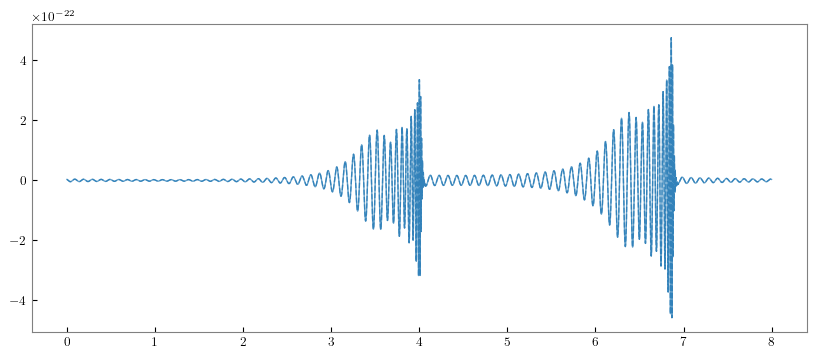

In [ ]:
sampling_frequency = 2048.  # Hz
duration = 8.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, shape), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, shape), (0,))

cplx_zeros = np.zeros((freq_array.size, shape), dtype=np.complex128)
# Make use of jax numpy `.at.set` copying feature
H1_lensed_strain = cplx_zeros.at[freq_mask].set(H1_Lensed.GWstrain(masked_freq_grid, lensed_params))
H1_unlensed_strain = cplx_zeros.at[freq_mask].set(H1_BBH.GWstrain(masked_freq_grid, lensing_parameters))

H1_normal_lensed_strain = normal_lens(H1_unlensed_strain, lensing_parameters, freq_grid)

psd_interp = np.interp(freq_array, H1.psd_frequencies, H1.psd_array)
psd_interp_grid = broadcast_in_dim(psd_interp, (N_freq_bins, shape), (0,))
_mismatch = mismatch(freq_grid, H1_lensed_strain, H1_normal_lensed_strain, psd_interp_grid)    
print(_mismatch)

H1_lensed_TD_strain = np.fft.irfft(H1_lensed_strain, axis=0) * sampling_frequency
H1_normal_lensed_TD_strain = np.fft.irfft(H1_normal_lensed_strain, axis=0) * sampling_frequency

post_merger_time = -4
n_index = int(post_merger_time * sampling_frequency)
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

for idx, (h1, h2) in enumerate(zip(H1_lensed_TD_strain.T, H1_normal_lensed_TD_strain.T)):
    if idx != 0:
        continue
    ax.plot(time_array, np.roll(h1, n_index), c=f'C{idx}', label='flexible', alpha=0.7)
    ax.plot(time_array, np.roll(h2, n_index), c=f'C{idx}', label='normal', ls='--', alpha=0.7)

# ax.set_xlim(3, 5.5)

## Check lensed parameters

In [7]:
lensed_params['dL_1'], lensing_parameters['dL'] / agn_lensed_params['sqrt_mu_p'], \
lensed_params['dL_2'], lensing_parameters['dL'] / agn_lensed_params['sqrt_mu_m']

(Array([2.02152735, 5.18330511, 9.85638174], dtype=float64),
 Array([2.02152735, 5.18330511, 9.85638174], dtype=float64),
 Array([1.42176352, 1.86591565, 1.96005519], dtype=float64),
 Array([1.42176352, 1.86591565, 1.96005519], dtype=float64))

In [6]:
agn_lensed_params['z_rel_p'], agn_lensed_params['z_rel_m']

(Array([0.01542517, 0.02300554, 0.02996571], dtype=float64),
 Array([-0.00363411,  0.00324146,  0.01054169], dtype=float64))

In [ ]:
H1_AGN.convert_to_general_lensed_parameters(lensing_parameters)

{'tcoal': Array([0., 0., 0.], dtype=float64),
 'chi1z': Array([0.3, 0.3, 0.3], dtype=float64),
 'Mc': Array([80.82682274, 81.43021283, 81.98423515], dtype=float64),
 'theta': Array([0.1, 0.1, 0.1], dtype=float64),
 'iota': Array([1.51071146, 1.54044511, 1.54648405], dtype=float64),
 'chi2z': Array([0.4, 0.4, 0.4], dtype=float64),
 'dL': Array([ 2.07392509,  5.39734703, 10.40352806], dtype=float64),
 'psi': Array([0.3, 0.3, 0.3], dtype=float64),
 'R_orbit': Array([100., 100., 100.], dtype=float64),
 'phi': Array([0.3, 0.3, 0.3], dtype=float64),
 'M_lz': Array([500000., 500000., 500000.], dtype=float64),
 'eta': Array([0.23, 0.23, 0.23], dtype=float64),
 'src_pos': Array([-0.05, -0.15, -0.25], dtype=float64),
 'phase': Array([2.23429497, 2.24067856, 2.24117678], dtype=float64),
 'delta_iota': Array([0.08875382, 0.02928652, 0.01720863], dtype=float64),
 'delta_phase': Array([-0.26858994, -0.28135712, -0.28235356], dtype=float64),
 'relative_distance': Array([0.67715735, 0.34621048, 0.1914